# **1. Predictive Modeling**

## **Database**

- user_id
- age
- visit_day (Weekday or Weekend)
- channel (Web, Mobile, In-Park, or Unknown)
- food_merch_spend (combined food and merchandise spend)
- promo_group (Control or Treatment for a discount experiment)
- ticket_purchase (binary)
- park (SeaWorld Orlando, Busch Gardens Tampa, or Aquatica San Diego)
- **express_pass_upgrade (binary – target variable)**



**Objective: classification model to predict express_pass_upgrade**

In [1]:
!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

In [2]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [53]:
# URL file: https://drive.google.com/file/d/1UfpDOQ-MoYGhezlIHRdzIvzf_Zto_Elu/view?usp=sharing
file_id = '1UfpDOQ-MoYGhezlIHRdzIvzf_Zto_Elu'
fileDownloaded = drive.CreateFile({'id': file_id})

In [84]:
# Export the Google Sheet as an Excel file and download it.
fileDownloaded.GetContentFile('united_parks_ds_assessment_express_pass.csv')

In [85]:
import pandas as pd
df = pd.read_csv("/content/united_parks_ds_assessment_express_pass.csv")


# Show
df.head(10)

,user_id,age,visit_day,channel,food_merch_spend,promo_group,ticket_purchase,park,express_pass_upgrade
0,1,56.0,Weekday,Mobile,69.76,Treatment,0,SeaWorld Orlando,0
1,2,46.0,Weekend,In-Park,115.00,Treatment,0,Busch Gardens Tampa,0
2,3,32.0,Weekend,Mobile,138.27,Treatment,1,Aquatica San Diego,0
3,4,60.0,Weekend,Mobile,130.47,Treatment,1,Aquatica San Diego,0
4,5,25.0,Weekday,Mobile,94.66,Treatment,1,Aquatica San Diego,1
5,6,38.0,Weekday,Mobile,137.27,Control,0,Aquatica San Diego,0
6,7,56.0,Weekday,Web,103.72,Control,0,Aquatica San Diego,0
7,8,36.0,Weekday,Unknown,91.57,Control,0,Aquatica San Diego,1
8,9,40.0,Weekday,Web,84.66,Treatment,0,Busch Gardens Tampa,0
9,10,28.0,Weekday,In-Park,92.44,Control,0,SeaWorld Orlando,0


## **Missing values**

In [86]:
df.shape

(1000, 9)

In [87]:
df.isna().sum()

,0
user_id,0
age,25
visit_day,0
channel,0
food_merch_spend,0
promo_group,0
ticket_purchase,0
park,0
express_pass_upgrade,0


In [88]:
# 25 missing values represent only the 2.5% of the data.
# I could replace them by using the median or the mean of the feature "age" or I could just drop them

df = df.dropna()

In [89]:
df.isna().sum()

,0
user_id,0
age,0
visit_day,0
channel,0
food_merch_spend,0
promo_group,0
ticket_purchase,0
park,0
express_pass_upgrade,0


## **Outliers**

In [90]:
# It wont be neccesary for the analysis to use user_id so I will drop it
df = df.drop('user_id', axis=1)

In [91]:
df.dtypes

,0
age,float64
visit_day,object
channel,object
food_merch_spend,float64
promo_group,object
ticket_purchase,int64
park,object
express_pass_upgrade,int64


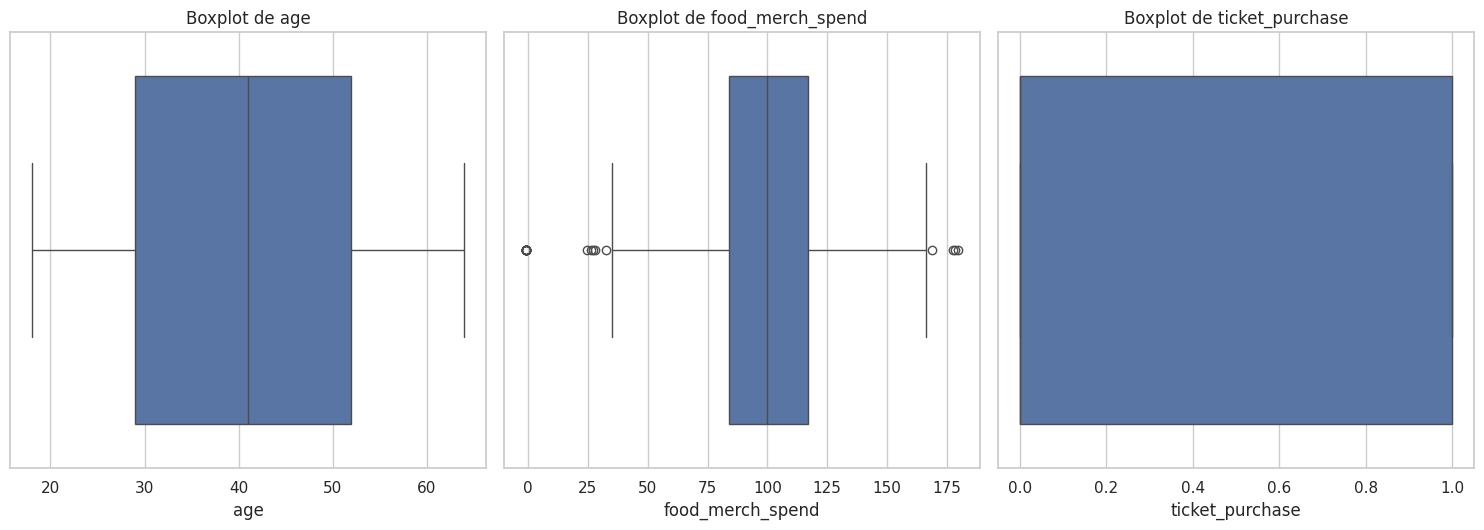

In [92]:
# Verify outliers
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric colums
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Exclude target
numeric_columns = numeric_columns.drop('express_pass_upgrade')

# Boxplot
plt.figure(figsize=(15, 10))

# Loop
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 3 + 1, 3, i)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot de {column}')
    plt.tight_layout()

plt.show()

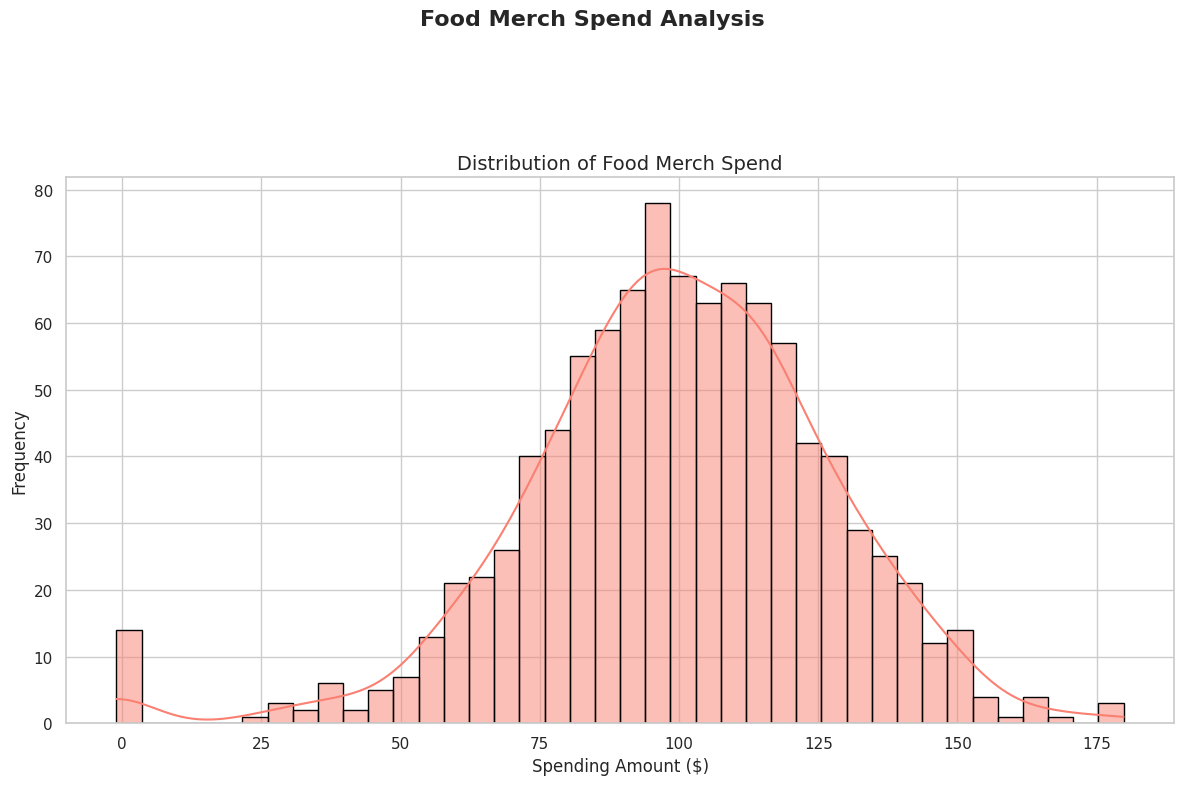

In [93]:
# Check the distribution of food_merch_spend

import seaborn as sns
import matplotlib.pyplot as plt


sns.set(style="whitegrid")


fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [0.1, 1]})
fig.suptitle('Food Merch Spend Analysis', fontsize=16, fontweight='bold')

# Histoplot
sns.histplot(df['food_merch_spend'],
             bins=40,
             kde=True,
             ax=axes[1],
             color='salmon',
             edgecolor='black')


axes[1].set_title('Distribution of Food Merch Spend', fontsize=14)
axes[1].set_xlabel('Spending Amount ($)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)


axes[0].axis('off')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [94]:
df.describe()

,age,food_merch_spend,ticket_purchase,express_pass_upgrade
count,975.000000,975.000000,975.000000,975.000000
mean,40.803077,99.436123,0.269744,0.196923
std,13.453479,27.528997,0.444054,0.397878
min,18.000000,-1.000000,0.000000,0.000000
25%,29.000000,83.880000,0.000000,0.000000
50%,41.000000,100.010000,0.000000,0.000000
75%,52.000000,116.890000,1.000000,0.000000
max,64.000000,179.830000,1.000000,1.000000


In [95]:
# I want to see the rows where the money spend in food and merch are below 0
negative_spend_count = df[df['food_merch_spend'] < 0].shape[0]
print(f"Number of cases where food_merch_spend is less than 0: {negative_spend_count}")

df[df['food_merch_spend'] < 0]

Number of cases where food_merch_spend is less than 0: 14


,age,visit_day,channel,food_merch_spend,promo_group,ticket_purchase,park,express_pass_upgrade
15,20.0,Weekday,Web,-1.0,Treatment,0,SeaWorld Orlando,0
87,42.0,Weekday,Unknown,-1.0,Control,0,SeaWorld Orlando,0
150,47.0,Weekend,Unknown,-1.0,Control,0,Aquatica San Diego,0
187,44.0,Weekday,In-Park,-1.0,Control,1,Busch Gardens Tampa,0
203,54.0,Weekday,Unknown,-1.0,Control,0,Aquatica San Diego,0
253,28.0,Weekend,Web,-1.0,Control,1,Aquatica San Diego,0
281,25.0,Weekday,Unknown,-1.0,Control,0,Aquatica San Diego,0
328,22.0,Weekend,Mobile,-1.0,Control,0,SeaWorld Orlando,0
396,51.0,Weekend,Web,-1.0,Treatment,0,Busch Gardens Tampa,1
516,19.0,Weekend,Mobile,-1.0,Control,0,SeaWorld Orlando,0


In [96]:
# Drop these outliers

df = df[df['food_merch_spend'] >= 0]

In [97]:
df.shape

(961, 8)

## **Distribution of classes**

In [34]:
# Check if the is unbalance classes
print(df['express_pass_upgrade'].value_counts())

express_pass_upgrade
0    771
1    190
Name: count, dtype: int64


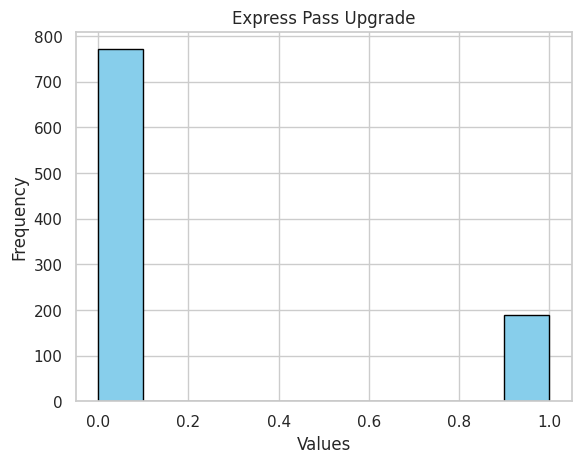

In [35]:
# Graphic

import matplotlib.pyplot as plt
import numpy as np


plt.hist(df['express_pass_upgrade'], color='skyblue', edgecolor='black')


plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Express Pass Upgrade')


plt.show()

## **Prepare dataset**

In [36]:
# Apply dummies for categorical features

df = pd.get_dummies(df, dtype=int)
df.head()

,age,food_merch_spend,ticket_purchase,express_pass_upgrade,visit_day_Weekday,visit_day_Weekend,channel_In-Park,channel_Mobile,channel_Unknown,channel_Web,promo_group_Control,promo_group_Treatment,park_Aquatica San Diego,park_Busch Gardens Tampa,park_SeaWorld Orlando
0,56.0,69.76,0,0,1,0,0,1,0,0,0,1,0,0,1
1,46.0,115.00,0,0,0,1,1,0,0,0,0,1,0,1,0
2,32.0,138.27,1,0,0,1,0,1,0,0,0,1,1,0,0
3,60.0,130.47,1,0,0,1,0,1,0,0,0,1,1,0,0
4,25.0,94.66,1,1,1,0,0,1,0,0,0,1,1,0,0


In [37]:
# Normalize data
data = (df- df.min()) / (df.max() - df.min())
data.head()

,age,food_merch_spend,ticket_purchase,express_pass_upgrade,visit_day_Weekday,visit_day_Weekend,channel_In-Park,channel_Mobile,channel_Unknown,channel_Web,promo_group_Control,promo_group_Treatment,park_Aquatica San Diego,park_Busch Gardens Tampa,park_SeaWorld Orlando
0,0.826087,0.291334,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.608696,0.582604,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.304348,0.732423,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0.913043,0.682204,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.152174,0.451648,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [38]:
# Convert to float32 to use GPU
data = data.astype(np.float32)

In [39]:
# Verify
data.dtypes

,0
age,float32
food_merch_spend,float32
ticket_purchase,float32
express_pass_upgrade,float32
visit_day_Weekday,float32
visit_day_Weekend,float32
channel_In-Park,float32
channel_Mobile,float32
channel_Unknown,float32
channel_Web,float32


In [40]:
# X and y
X = data.drop("express_pass_upgrade", axis=1)
y = data[["express_pass_upgrade"]]

## **Random Forest**

### **Imbalance data**

F1 Score: 0.12658227848101267
Precision: 0.22727272727272727
Recall: 0.08771929824561403


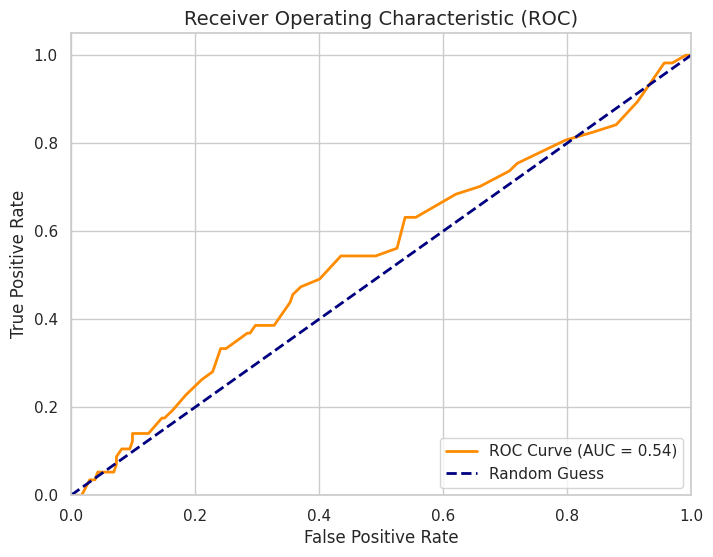

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score

def f1_precision_recall_with_auc(X, y):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, shuffle=True, stratify=y, random_state=2025
    )

    # Model
    clf = RandomForestClassifier(random_state=2025)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]  # Probabilidad para clase positiva

    # Metrics
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))

    # ROC y AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC)', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


f1_precision_recall_with_auc(X, y)


### **Balance data with SMOTE**

In [46]:
# Balance classes using SMOTE
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
import imblearn

In [48]:
# Apply SMOTE
smote = imblearn.over_sampling.SMOTE(random_state=2025)
X_smote, y_smote = smote.fit_resample(X, y)

# Verify SMOTE
print(f"Distribution of classes with SMOTE: {y_smote.value_counts()}")

Distribution of classes with SMOTE: express_pass_upgrade
0.0                     771
1.0                     771
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


F1 Score: 0.8
Precision: 0.787
Recall: 0.814


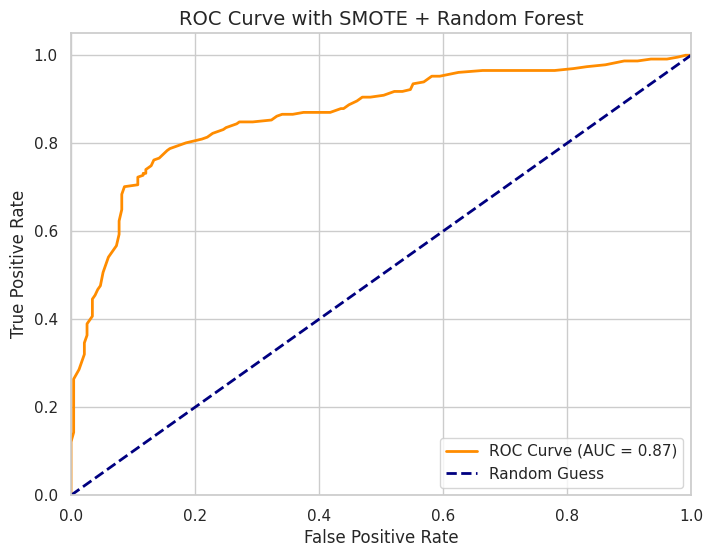

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

def evaluate_model_with_smote(X, y):
    # Split SMOTE data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, shuffle=True, stratify=y, random_state=2025
    )

    # Model
    clf = RandomForestClassifier(random_state=2025)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # Metrics
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print("F1 Score:", round(f1, 3))
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))

    # ROC y AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve with SMOTE + Random Forest', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Balanced data
evaluate_model_with_smote(X_smote, y_smote)


## **Trade-offs and Business Recommendation**

**Model Trade-offs**

In building the classification model to predict **express_pass_upgrade** , one key trade-off was between **precision** and **recall**:

* A model with **high recall** captures most users who are likely to upgrade, but at the cost of including more false positives (users flagged as likely to upgrade, but who don’t).
* A model with **high precision** is more accurate in identifying true upgraders, but may miss potential customers (false negatives).

The optimal balance depends on business priorities:

* If the goal is to **maximize upgrade conversions**, favoring **recall** helps reach more potential upgraders, even at some cost.
* If the goal is to **optimize marketing costs**, **precision** ensures resources are focused on the most likely converters.

**Business Recommendation**

**Recommendation**: Launch a targeted campaign (e.g., email or app push) to users with a **high predicted probability of upgrading**, offering a limited-time incentive (e.g., discount or early access) to drive immediate conversion.

Additionally, use the model to **prioritize high-value segments** (e.g., frequent visitors, high spenders on food or merchandise) in order to **maximize ROI from the Express Pass upgrade program**.



# **2. A/B Testing & Causal Inference**

## **Estimate the effect of promo_group on ticket_purchase**

In [57]:
# Verify que promo_group
df['promo_group'].value_counts()

,count
promo_group,
Control,513
Treatment,487


In [58]:
# Conversion rates
conversion_rates = df.groupby('promo_group')['ticket_purchase'].mean()
print(conversion_rates)

promo_group
Control      0.272904
Treatment    0.268994
Name: ticket_purchase, dtype: float64


In [65]:
ate = conversion_rates[1] - conversion_rates[0]
print(f"Estimated ATE (Effect of promo): {ate:.4f}")

Estimated ATE (Effect of promo): -0.0039


/tmp/ipython-input-65-2721446992.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ate = conversion_rates[1] - conversion_rates[0]


## **Test for statistical significance**

In [63]:
from statsmodels.stats.proportion import proportions_ztest

# ticket purchase by group
successes = df.groupby('promo_group')['ticket_purchase'].sum().values
n_obs = df['promo_group'].value_counts().sort_index().values

# Test Z
z_stat, p_value = proportions_ztest(successes, n_obs)
print(f"Z-stat: {z_stat:.2f}, p-value: {p_value:.4f}")


Z-stat: 0.14, p-value: 0.8894


The difference in ticket purchase rates between the control and treatment groups is very small (−0.39%), and not statistically significant (p = 0.8894). This suggests that, based on the current data, the promotional campaign did not have a measurable impact on ticket purchases.

## **Discuss any potential confounders and how you'd control for them**

**Potential Confounders**

Even though the results are non-significant, we still need to consider whether external factors might be hiding a true effect:

- Customer type: Frequent buyers may be more likely to purchase, regardless of promo.

- Seasonality: If one group had more users during peak times, it could skew results.

- Targeting bias: If users weren't randomly assigned to promo/control, selection effects might bias outcomes.

**Business Recommendation**
Based on the current analysis, there is no evidence that the promotion significantly increased ticket purchases. I recommend:

- Not rolling out this promotion at scale until further testing.

- Running a properly randomized A/B test to remove potential confounding variables.

- Clustering. Exploring segmented effects, promotion may still be effective for specific user groups (e.g., first-time visitors, high-spending segments).

# **3. Communication & Visualization**

## **Create one clear chart revealing an insight**

In [71]:
# upgrade rates by day
df_clean = df.dropna(subset=['visit_day', 'express_pass_upgrade'])
df_clean['express_pass_upgrade'] = df_clean['express_pass_upgrade'].astype(float)

upgrade_rates = df_clean.groupby('visit_day')['express_pass_upgrade'].mean()
print(upgrade_rates)


visit_day
Weekday    0.209125
Weekend    0.185654
Name: express_pass_upgrade, dtype: float64


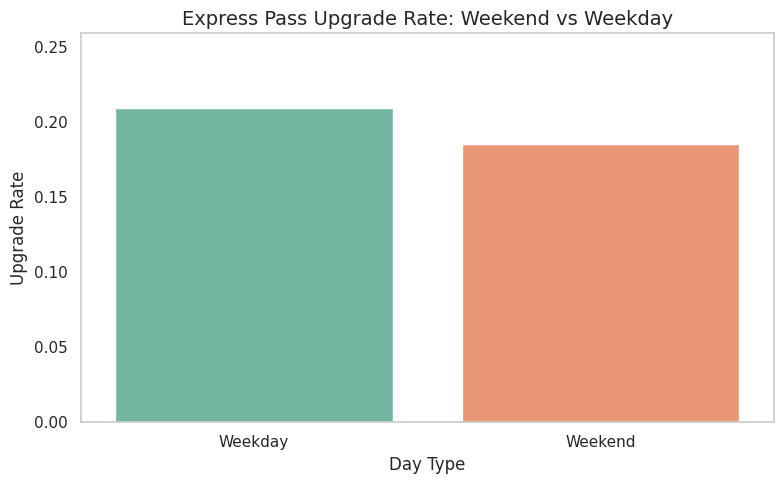

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# Graphic
plt.figure(figsize=(8, 5))
sns.barplot(data=upgrade_by_daytype, x='visit_day', y='express_pass_upgrade', palette='Set2')
plt.title('Express Pass Upgrade Rate: Weekend vs Weekday', fontsize=14)
plt.xlabel('Day Type')
plt.ylabel('Upgrade Rate')
plt.ylim(0, upgrade_by_daytype['express_pass_upgrade'].max() + 0.05)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Express Pass upgrades are slightly higher on weekdays (21%) compared to weekends (18%).

Implication: Visitors may be more price-sensitive or time-conscious during weekdays, potentially due to tighter schedules or shorter visits.

**Recommendation**: Consider targeting weekday guests with personalized upgrade offers or bundling options, as they show a higher conversion tendency. On weekends, test incentives or urgency messaging to boost interest.



# **4. Clustering (Unsupervised Learning)**

In [98]:
X = df.drop("express_pass_upgrade", axis=1)

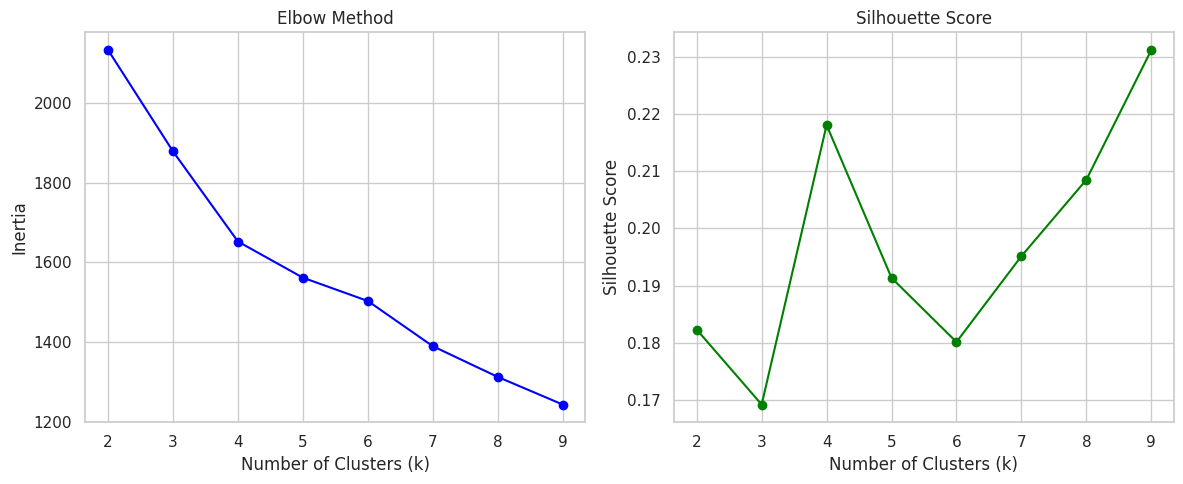

In [102]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Exclude the target variable 'express_pass_upgrade'
X = data.drop("express_pass_upgrade", axis=1)


# k range
k_range = range(2, 10)
inertia = []
silhouette = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=2025, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, kmeans.labels_))

# Elbow method and Silhouette score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'o-', color='blue')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette, 'o-', color='green')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

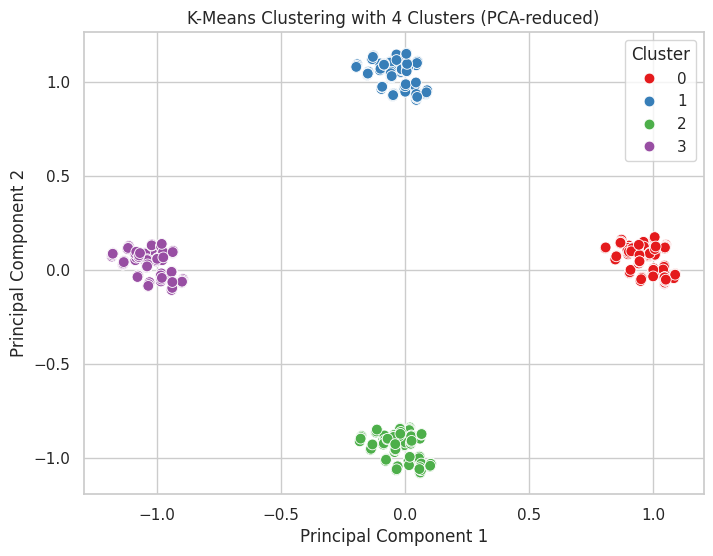

In [107]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# KMeans 4 clusters
kmeans = KMeans(n_clusters=4, random_state=2025, n_init=10)
clusters = kmeans.fit_predict(X)

# Reduce to 2D for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create dataframe with PCA and clusters
import pandas as pd
df_vis = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_vis["Cluster"] = clusters

# Graphic
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_vis, x="PC1", y="PC2", hue="Cluster", palette="Set1", s=60)
plt.title("K-Means Clustering with 4 Clusters (PCA-reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


In [109]:
# Clusters to original DataFrame
data_with_clusters = data.copy()
data_with_clusters["Cluster"] = clusters

# Clusters
cluster_sizes = data_with_clusters["Cluster"].value_counts().sort_index()

print("Cluster sizes:\n", cluster_sizes)



Cluster sizes:
 Cluster
0    258
1    212
2    250
3    241
Name: count, dtype: int64


In [110]:
# Clusters avg
cluster_summary = data_with_clusters.groupby("Cluster").mean()

In [112]:
cluster_summary

,age,food_merch_spend,ticket_purchase,express_pass_upgrade,visit_day_Weekday,visit_day_Weekend,channel_In-Park,channel_Mobile,channel_Unknown,channel_Web,promo_group_Control,promo_group_Treatment,park_Aquatica San Diego,park_Busch Gardens Tampa,park_SeaWorld Orlando
Cluster,,,,,,,,,,,,,,,
0,0.494523,0.489490,0.224806,0.248062,1.0,0.0,0.228682,0.232558,0.251938,0.286822,0.0,1.0,0.294574,0.360465,0.344961
1,0.476415,0.515805,0.325472,0.221698,0.0,1.0,0.231132,0.273585,0.245283,0.250000,0.0,1.0,0.316038,0.339623,0.344340
2,0.508956,0.484603,0.268000,0.168000,1.0,0.0,0.220000,0.276000,0.268000,0.236000,1.0,0.0,0.300000,0.392000,0.308000
3,0.500541,0.480697,0.278008,0.153527,0.0,1.0,0.215768,0.311203,0.236515,0.236515,1.0,0.0,0.336100,0.327801,0.336100



### Cluster Interpretation and Segment Names

#### **Cluster 0**

* Visits on **weekdays** (`Weekday = 1.0`)
* Assigned to **promotion treatment group**
* Moderate ticket and express pass purchases
* Relatively balanced across parks

**Suggested Name**:
**“Weekday Visitors Responsive to Promotions”**
→ Regular visitors during the week who are influenced by promotions.

----

#### **Cluster 1**

* Visits on **weekends** (`Weekend = 1.0`)
* Highest **ticket** and **express pass upgrade** rates
* High use of **mobile** and **web** channels
* In the **promotion treatment group**

**Suggested Name**:
**“Engaged Weekend Shoppers”**
→ Higher spenders who buy upgrades and are likely influenced by marketing, especially on weekends.

---

#### **Cluster 2**

* Visits on **weekdays**
* In the **control group** (no promo exposure)
* Low express pass upgrades
* Average food/merch spend

**Suggested Name**:
**“Passive Weekday Visitors (Unexposed to Promotions)”**
→ Less engaged, potentially habitual or low-value visitors, not influenced by promotional efforts.

---

#### **Cluster 3**

* Visits on **weekends**
* In the **control group**
* Lowest express pass upgrade rate
* Mobile channel usage is high

**Suggested Name**:
**“Spontaneous Weekend Visitors (No Premium Spend)”**
→ Weekend guests who do not engage in upselling or upgrades, possibly day-trippers or first-timers.

---

### Final Segment Summary:

| Cluster | Segment Name                                       |
| ------- | -------------------------------------------------- |
| 0       | Weekday Visitors Responsive to Promotions          |
| 1       | Engaged Weekend Shoppers                           |
| 2       | Passive Weekday Visitors (Unexposed to Promotions) |
| 3       | Spontaneous Weekend Visitors (No Premium Spend)    |

